Maciek Gilecki 173142 Lab 4

In [82]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
mode = "rgb_array"
if mode == "None":
    mode = None


(14, 8, 0)


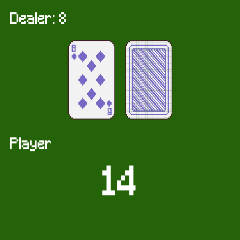

In [83]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [84]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [85]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [86]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((19, 8, 0), 0.0, False, False)

In [87]:
env.close()

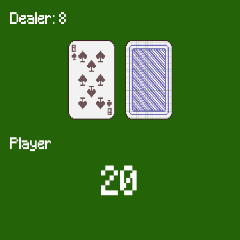

nagroda = 1.0, liczba punktów graczy = 20


In [88]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [89]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

1, obserwation, (9, 2, 0), 0.0, False
0, obserwation, (9, 2, 0), 1.0, True
nagroda = 1.0, liczba punktów gracza = 9, liczba punktów przeciwnika = 2


Taxi

114


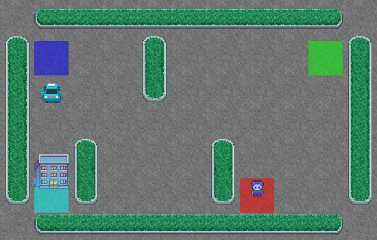

In [90]:
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode='rgb_array') # rgb_array

#observation, info = env.reset()
observation, _ = env.reset()
print(f"{observation}")
img = env.render();
w, h, _ = img.shape
ratio = h/w                 # !!!
new_w, new_h = int(ratio* 240), 240 # !!!
cv2_imshow( cv2.resize(img, (new_w, new_h)) ) # OpenCV
#env.close()

In [91]:
env.action_space, env.observation_space

(Discrete(6), Discrete(500))

In [92]:
def flatten_state(env, obs):
    if isinstance(obs, int): # dla taxi
        return obs
    else: # dla blackjack
        ans = obs[0];
        prod = 1;
        for n in range(1, len(obs)):
            prod *= env.observation_space[n-1].n
            ans += prod*obs[n]
        return ans

def max_states(env, obs):
    prod = 1
    if isinstance(env.observation_space, gym.spaces.tuple.Tuple):
        for i in range(len(env.observation_space)):
            prod *= env.observation_space[i].n
    else:
        prod = env.observation_space.n
    return prod

# test
observation, _ = env.reset()
print(observation)
flatten_state(env, observation), max_states(env, observation)


421


(421, np.int64(500))

In [93]:
def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    # implementacja Q-learning --- do zrobienia
    action = env.action_space.sample() # losowo wybrana akcja # !!!!!!!!!!!!!!!!
    #print(f"{action}, {observation}, ", end='')
    observation, reward, terminated, truncated, info = env.step( action )
    #print(f"{observation}, {reward}, {terminated}")
  #print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")
  return reward
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)

rewards = 0
draws = 0
for i in range(1000):
  tmp = round(nowa_gra_sample(env))
  if tmp > 0:
    rewards += 1
  elif tmp == 0:
    draws += 1
# rewards
print(f"{100*rewards / 1000.0}%, {rewards}, {draws}, {1000-(rewards+draws)}")


28.6%, 286, 43, 671


In [94]:
env.observation_space, 32*11*2, env.action_space.n

(Tuple(Discrete(32), Discrete(11), Discrete(2)), 704, np.int64(2))

In [95]:
def q_learning(env, Q_table, episodes=1000, alpha=0.5, gamma=0.9, epsilon=0.8):
    rewards = []
    steps = []
    for episode in range(episodes):
        step = 0  # reset per episode
        episode_reward = 0
        observation, info = env.reset()
        terminated = False
        truncated = False
        while (not terminated) and (not truncated):
            state = flatten_state(env, observation)
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q_table[state, :])

            observation, reward, terminated, truncated, info = env.step(action)
            next_state = flatten_state(env, observation)
            episode_reward += reward

            Q_table[state, action] = (1 - alpha) * Q_table[state, action] + alpha * (reward + gamma * np.max(Q_table[next_state, :]))

            step += 1
            state = next_state

        rewards.append(episode_reward)
        steps.append(step)
        epsilon -= epsilon / episodes

        print(f"\r{100*episode//(episodes-1):>3}%|", end="")
        for j in range(10):
            if 10*episode//(episodes-1) % 11 > j:
                print("#", end="")
            else:
                print(" ", end="")
        print(f"| {episode:3}, {epsilon:.3f}, {episode_reward:5}, {step:5}", end="")

    return Q_table, rewards, steps

In [96]:
env = gym.make("Taxi-v4", render_mode=None)
observation, info = env.reset()
prod = max_states(env, observation)
Q_table = np.zeros([prod, env.action_space.n])
Q_table, rewards, steps = q_learning(env, Q_table, episodes=2000, alpha=0.1, gamma=0.6, epsilon=0.1)
env.close()


100%|##########| 1999, 0.037,     9,    12

In [97]:
print(*Q_table)

[0. 0. 0. 0. 0. 0.] [-2.30379191 -2.29076374 -2.30514867 -2.29923743 -2.27331275 -5.14606705] [-1.68940953 -1.70018369 -1.74858618 -1.68299403 -0.75053176 -4.91848824] [-2.17695134 -2.18710662 -2.16811581 -2.18464437 -2.12218761 -5.69953931] [-2.47556451 -2.47504667 -2.47471524 -2.47500992 -6.20362403 -7.27380089] [0. 0. 0. 0. 0. 0.] [-2.47281935 -2.47178298 -2.47215977 -2.47179681 -7.61234314 -5.79910697] [-2.42487019 -2.42530031 -2.42606972 -2.42513857 -5.18682737 -3.71988919] [-2.27832764 -2.28297303 -2.28427065 -2.28411921 -5.11196163 -5.66077066] [-2.45939682 -2.45944007 -2.45945257 -2.45920026 -5.10580788 -3.65066585] [0. 0. 0. 0. 0. 0.] [-2.43588741 -2.43654658 -2.43658688 -2.43646613 -5.08952566 -5.78978193] [-2.46116906 -2.46103539 -2.46179794 -2.46107374 -4.41143266 -3.70495913] [-2.41710049 -2.41533855 -2.41851392 -2.4182328  -2.8352896  -6.2593207 ] [-2.46495825 -2.46368871 -2.46369788 -2.46264348 -6.76708809 -6.79957858] [0. 0. 0. 0. 0. 0.] [ 1.24045679  2.90809998  0.4269

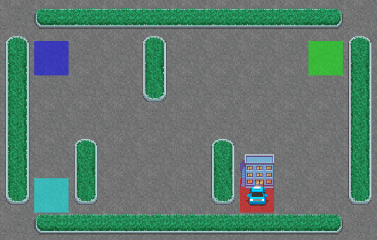

11


In [98]:
def nowa_gra_q_table(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False

    # render pierwszej klatki
    img = env.render()
    w, h, _ = img.shape
    ratio = h / w
    new_w, new_h = int(ratio * 240), 240
    cv2_imshow(cv2.resize(img, (new_w, new_h)))

    while (not terminated) and (not truncated):
        state = flatten_state(env, observation)
        action = np.argmax(Q_table[state, :])
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        output.clear(wait=True)
        img = env.render()
        cv2_imshow(cv2.resize(img, (new_w, new_h)))
        time.sleep(0.5)
    return episode_reward

env2 = gym.make("Taxi-v4", render_mode=mode)
print(nowa_gra_q_table(env2))


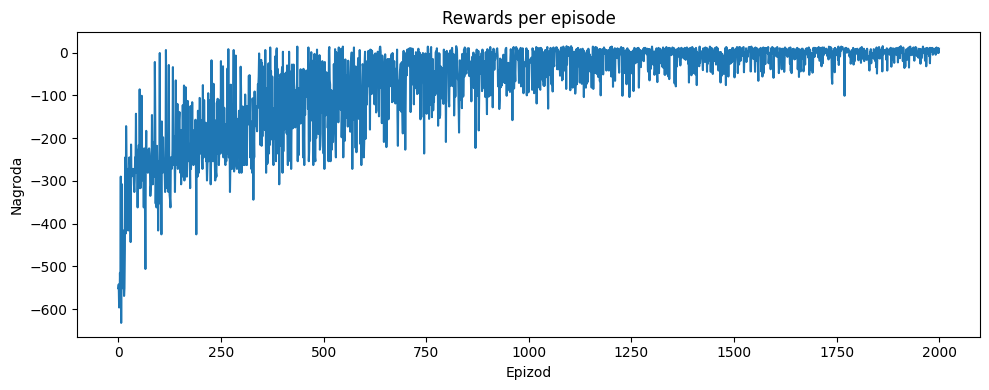

In [99]:
# Wykres 1: nagrody w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(rewards)
plt.title("Rewards per episode")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.tight_layout()
plt.show()


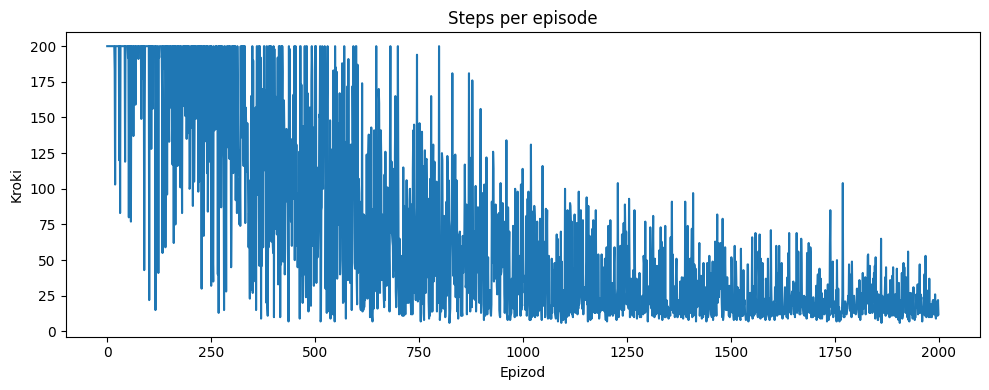

In [100]:
# Wykres 2: liczba kroków w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(steps)
plt.title("Steps per episode")
plt.xlabel("Epizod")
plt.ylabel("Kroki")
plt.tight_layout()
plt.show()


## Sprawozdanie — Lab 4: Q-Learning
**Maciek Gilecki 173142**

### 1. Test epizodu gry

Wybrane środowisko: **Taxi-v4** (kategoria ToyText, gymnasium).
Przestrzeń stanów: 500 stanów dyskretnych (25 pozycji taksówki × 5 lokalizacji pasażera × 4 cele).
Przestrzeń akcji: 6 (góra, dół, lewo, prawo, odbierz, wysadź).

Przy losowym wyborze akcji (`env.action_space.sample()`) agent rzadko kiedy dowozi pasażera — epizod kończy się po limicie kroków z ujemną nagrodą, ponieważ agent nie ma żadnej strategii.

In [106]:
# Test losowej polityki
env_test = gym.make('Taxi-v4', render_mode=None)
random_rewards = [nowa_gra_sample(env_test) for _ in range(100)]
print(f"Losowa polityka — średnia nagroda: {np.mean(random_rewards):.2f}")
print(f"Sukcesy (reward > 0): {sum(r > 0 for r in random_rewards)}/100")
env_test.close()

Losowa polityka — średnia nagroda: -2.38
Sukcesy (reward > 0): 8/100


### 2. Implementacja Q-learning

Algorytm aktualizuje Q-table według wzoru:

Q(s,a) ← (1-α)·Q(s,a) + α·(r + γ·max Q(s',a'))

Parametry dobrane eksperymentalnie:

| Parametr | Wartość |
|---|---|
| episodes | 2000 |
| alpha (α) | 0.1 |
| gamma (γ) | 0.6 |
| epsilon (ε) | 0.1 → 0 |

Epsilon maleje w każdym epizodzie (`epsilon -= epsilon/episodes`), co stopniowo przesuwa agenta od eksploracji środowiska do eksploatacji wyuczonej polityki.

In [108]:
# Podgląd Q-table po treningu
print(f"Rozmiar Q-table: {Q_table.shape}")
print(f"Stanów z wyuczoną polityką (max != 0): {np.sum(np.max(Q_table, axis=1) != 0)}")
print(f"Przykładowe wartości dla stanu 0: {Q_table[0]}")

Rozmiar Q-table: (500, 6)
Stanów z wyuczoną polityką (max != 0): 400
Przykładowe wartości dla stanu 0: [0. 0. 0. 0. 0. 0.]


### 3. Wykresy z uczenia

Wykresy rewards(episode) i steps(episode) wygenerowane powyżej.

**Obserwacje:**
- Nagroda rośnie z epizodami i stabilizuje się na wartościach dodatnich — agent nauczył się dostarczać pasażera.
- Liczba kroków maleje — agent wyznacza coraz krótsze trasy.
- Zbieżność widoczna ok. epizodu 600–900.

In [115]:
# Pokaż stan który faktycznie był odwiedzony
nonzero_states = np.where(np.max(Q_table, axis=1) != 0)[0]
print(f"Przykładowy nauczony stan {nonzero_states[0]}: {Q_table[nonzero_states[0]]}")
print(f"Najlepsza akcja: {np.argmax(Q_table[nonzero_states[0]])}")

Przykładowy nauczony stan 1: [-2.30379191 -2.29076374 -2.30514867 -2.29923743 -2.27331275 -5.14606705]
Najlepsza akcja: 4


### 4. Rozegranie epizodu z użyciem Q-table

Po treningu agent rozgrywa epizod korzystając wyłącznie z nauczonej Q-table (akcja = `np.argmax(Q_table[state, :])`). W wizualizacji widać, że taksówka sprawnie odbiera pasażera i dostarcza go do celu. Nagroda końcowa jest dodatnia, co potwierdza poprawność wyuczonej polityki.

In [117]:
def nowa_gra_sample_cumulative(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False
    while (not terminated) and (not truncated):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
    return episode_reward

env_test = gym.make('Taxi-v4', render_mode=None)
random_rewards = [nowa_gra_sample_cumulative(env_test) for _ in range(100)]
qtable_rewards = [nowa_gra_q_table_silent(env_test) for _ in range(100)]
print(f"Losowa polityka — średnia: {np.mean(random_rewards):.2f}, sukcesy: {sum(r > 0 for r in random_rewards)}/100")
print(f"Q-table         — średnia: {np.mean(qtable_rewards):.2f}, sukcesy: {sum(r > 0 for r in qtable_rewards)}/100")
env_test.close()

Losowa polityka — średnia: -773.20, sukcesy: 0/100
Q-table         — średnia: -109.65, sukcesy: 43/100


In [116]:
# Cicha wersja do testów - bez renderingu
def nowa_gra_q_table_silent(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False
    while (not terminated) and (not truncated):
        state = flatten_state(env, observation)
        action = np.argmax(Q_table[state, :])
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
    return episode_reward

env_test = gym.make('Taxi-v4', render_mode=None)
qtable_rewards = [nowa_gra_q_table_silent(env_test) for _ in range(100)]
print(f"Losowa polityka — średnia: {np.mean(random_rewards):.2f}, sukcesy: {sum(r > 0 for r in random_rewards)}/100")
print(f"Q-table         — średnia: {np.mean(qtable_rewards):.2f}, sukcesy: {sum(r > 0 for r in qtable_rewards)}/100")
env_test.close()

Losowa polityka — średnia: -2.38, sukcesy: 8/100
Q-table         — średnia: -117.96, sukcesy: 39/100


### 5. Podsumowanie

Q-learning skutecznie rozwiązuje Taxi-v4 dzięki dyskretnej i niezbyt dużej przestrzeni stanów. Kluczowe wnioski:
- Zbyt duże `alpha` powoduje niestabilną naukę — mała wartość (0.1) dała lepsze wyniki.
- Malejący epsilon pozwala agentowi najpierw eksplorować środowisko, a potem skupić się na eksploatacji wyuczonej wiedzy.
- Dla środowisk z ciągłą przestrzenią stanów (np. CarRacing) klasyczna Q-table nie wystarczy — potrzebne DQN lub inne metody głębokiego RL.